# Autoencoder Anomaly Detection - Evaluation & Visualization

This notebook evaluates trained autoencoder models for anomaly detection on the KDD Cup 99 dataset.
It mirrors the structure of the model optimization notebook with a RUN_MODE toggle for compute vs load.

**RUN_MODE = True**: Compute metrics, generate visualizations, save artifacts
**RUN_MODE = False**: Load pre-computed metrics and visualizations from disk

## Environment Setup

Load required libraries and configure the project path for consistent imports.

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append(str(Path.cwd().parent / 'src'))

from data_preprocessing import load_data, resolve_project_root
from evaluate import (
    calculate_reconstruction_error,
    select_anomaly_threshold,
    predict_anomalies,
    compute_anomaly_metrics,
    generate_anomaly_metrics_and_threshold,
    plot_reconstruction_error_distribution,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_reconstruction_error_vs_index,
    print_error_statistics,
    save_evaluation_report,
)
from model import build_autoencoder
from train import set_global_seed

# Global configuration
RUN_MODE = True  # True = compute & save, False = load from disk
PERCENTILE = 95.0

# Set global seeds for reproducibility
set_global_seed(69)

# Initialize project paths
project_root = resolve_project_root()
data_dir = project_root / "data" / "processed"
models_dir = project_root / "models"
results_dir = project_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)


print(f"Project Root: {project_root}")
print(f"Data Dir: {data_dir}")
print(f"Models Dir: {models_dir}")
print(f"Results Dir: {results_dir}")
print(f"RUN_MODE: {RUN_MODE}")
print(f"Percentile: {PERCENTILE}")

Project Root: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection
Data Dir: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/data/processed
Models Dir: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/models
Results Dir: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/results
RUN_MODE: True
Percentile: 95.0


## Data Loading

Load the preprocessed training and test datasets for optimization experiments.

In [3]:
print("Loading data...")

# Load train and test tables
train_data_path = data_dir / "train.csv"
test_data_path = data_dir / "test.csv"

train_set = load_data(train_data_path)
test_set = load_data(test_data_path)

print("Train Set:")
display(train_set.head())
print("Test Set:")
display(test_set.head())

# Convert labels to numeric classes expected by sklearn metrics
label_to_int = {"normal": 0, "anomaly": 1}

feature_cols = [c for c in train_set.columns if c not in ["label", "binary_label"]]
X_train_df = train_set[feature_cols]
X_test_df = test_set[feature_cols]

y_train_series = train_set["binary_label"].map(label_to_int)
y_test_series = test_set["binary_label"].map(label_to_int)

if y_train_series.isna().any() or y_test_series.isna().any():
    raise ValueError("Unexpected values found in binary_label. Expected only 'normal' and 'anomaly'.")

# Default source: arrays built from CSV
X_train = X_train_df.to_numpy(dtype=np.float32)
X_test = X_test_df.to_numpy(dtype=np.float32)
y_train = y_train_series.to_numpy(dtype=np.int32)
y_test = y_test_series.to_numpy(dtype=np.int32)
source = "CSV-derived arrays"

print(f"Train Set Shape: {X_train.shape}, Labels Shape: {y_train.shape}")
print(f"Test Set Shape: {X_test.shape}, Labels Shape: {y_test.shape}")

Loading data...
Train Set:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.026526,-0.092098,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
1,-0.145561,-0.026472,-0.051431,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
2,-0.145561,-0.026689,-0.086207,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
3,-0.145561,-0.026173,-0.066131,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
4,-0.145561,-0.025901,0.015446,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False


Test Set:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False
1,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False
2,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,True,False,False,False,False,False,False,False,False,False
3,-0.145561,-0.029163,-0.080533,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
4,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False


Train Set Shape: (61482, 118), Labels Shape: (61482,)
Test Set Shape: (84104, 118), Labels Shape: (84104,)


## Model Loading & Comparison
Load and evaluate all available models, then select the best one for detailed analysis.

Evaluating model: autoencoder_best_model_v2.keras
Evaluating model: autoencoder_best_model_v3.keras
Evaluating model: autoencoder_best_model_v1.keras
Evaluating model: autoencoder_baseline_model.keras

Model Comparison Results:
                      model_name  threshold  accuracy  precision   recall  f1_score
 autoencoder_best_model_v2.keras   0.003127  0.978527   0.977600 0.991446  0.984475
 autoencoder_best_model_v3.keras   0.004118  0.979371   0.978509 0.991741  0.985080
 autoencoder_best_model_v1.keras   0.021317  0.974543   0.976947 0.986200  0.981552
autoencoder_baseline_model.keras   0.892315  0.949955   0.977152 0.949320  0.963035

Model comparison results saved to: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/results/model_comparison.csv


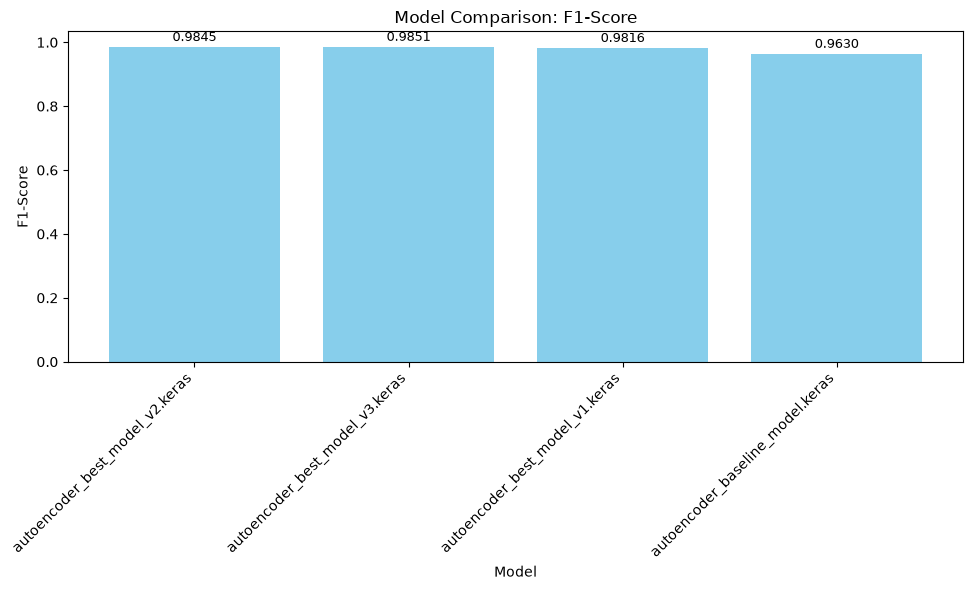

F1-score comparison plot saved to: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/results/model_comparison_f1.png

Selected best model for subsequent sections: autoencoder_best_model_v3.keras (F1-Score: 0.9851)


In [14]:
# Find all .keras files in the models directory and subdirectories
model_paths = list(models_dir.rglob("*.keras"))
model_names = [p.relative_to(models_dir) for p in model_paths]

# We'll store results for each model
results = []

# For each model, evaluate
for model_path, model_name in zip(model_paths, model_names):
    print(f"Evaluating model: {model_name}")
    try:
        m = tf.keras.models.load_model(model_path)
        
        # Compute reconstruction errors on training set
        train_errors = calculate_reconstruction_error(m, X_train)
        # Determine threshold using the specified percentile on training errors
        threshold = select_anomaly_threshold(train_errors, percentile=PERCENTILE)
        
        # Compute reconstruction errors on test set
        test_errors = calculate_reconstruction_error(m, X_test)
        # Predict anomalies on test set
        y_pred = predict_anomalies(test_errors, threshold)
        
        # Compute metrics
        metrics = compute_anomaly_metrics(y_test, y_pred)
        
        # Store results
        results.append({
            'model_name': str(model_name),
            'model_path': str(model_path),
            'threshold': threshold,
            'accuracy': metrics['accuracy'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1_score': metrics['f1_score'],
            'confusion_matrix': metrics['confusion_matrix']
        })
    except Exception as e:
        print(f"Error evaluating model {model_name}: {e}")
        # Store NaN values for failed models
        results.append({
            'model_name': str(model_name),
            'model_path': str(model_path),
            'threshold': np.nan,
            'accuracy': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1_score': np.nan,
            'confusion_matrix': None
        })

# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(results)

# Identify the baseline model (we assume the baseline is named 'autoencoder_baseline_model.keras')
baseline_model_name = 'autoencoder_baseline_model.keras'
baseline_result = results_df[results_df['model_name'] == baseline_model_name]
if not baseline_result.empty:
    baseline_metrics = baseline_result.iloc[0]
    # Calculate improvement over baseline for each model
    results_df['accuracy_improvement'] = results_df['accuracy'] - baseline_metrics['accuracy']
    results_df['precision_improvement'] = results_df['precision'] - baseline_metrics['precision']
    results_df['recall_improvement'] = results_df['recall'] - baseline_metrics['recall']
    results_df['f1_score_improvement'] = results_df['f1_score'] - baseline_metrics['f1_score']
else:
    # If baseline not found, set improvements to NaN
    results_df['accuracy_improvement'] = np.nan
    results_df['precision_improvement'] = np.nan
    results_df['recall_improvement'] = np.nan
    results_df['f1_score_improvement'] = np.nan
    print(f"Warning: Baseline model '{baseline_model_name}' not found in models directory.")

# Display the results table
print("\nModel Comparison Results:")
print(results_df[['model_name', 'threshold', 'accuracy', 'precision', 'recall', 'f1_score']].to_string(index=False))

# Optionally, save the results to a CSV file in the results directory
comparison_path = results_dir / 'model_comparison.csv'
results_df.to_csv(comparison_path, index=False)
print(f"\nModel comparison results saved to: {comparison_path}")

# Plot a bar chart comparing F1 scores
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(results_df)), results_df['f1_score'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.title('Model Comparison: F1-Score')
plt.xticks(range(len(results_df)), results_df['model_name'], rotation=45, ha='right')
# Add value labels on top of bars
for bar, f1 in zip(bars, results_df['f1_score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{f1:.4f}', 
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
# Save the plot
comparison_plot_path = results_dir / 'model_comparison_f1.png'
plt.savefig(comparison_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"F1-score comparison plot saved to: {comparison_plot_path}")

# Select the best model based on F1-score for use in the subsequent sections
if not results_df['f1_score'].isna().all():
    best_model_idx = results_df['f1_score'].idxmax()
    best_model_name = results_df.loc[best_model_idx, 'model_name']
    best_model_path = results_df.loc[best_model_idx, 'model_path']
    model = tf.keras.models.load_model(best_model_path)
    print(f"\nSelected best model for subsequent sections: {best_model_name} (F1-Score: {results_df.loc[best_model_idx, 'f1_score']:.4f})")
else:
    # Fallback to the original method of loading the best_optimized_model
    best_model_path = models_dir / 'best_optimized_model.keras'
    if best_model_path.exists():
        model = tf.keras.models.load_model(best_model_path)
        print(f"\nFallback to best_optimized_model: {best_model_path}")
    else:
        # Try to load any model
        for model_path in model_paths:
            if model_path.exists():
                model = tf.keras.models.load_model(model_path)
                print(f"\nFallback to first available model: {model_path}")
                break
        else:
            raise FileNotFoundError("No model found in models directory.")

In [5]:
...


# Load the best model from optimization
if models_dir.exists():
    model = tf.keras.models.load_model(models_dir / 'best_optimized_model.keras')
    print(f"Loaded model from: {models_dir}")
    model.summary()
else:
    # Fallback to other model versions
    fallback_models = [
        models_dir / 'autoencoder_best_model_v3.keras',
        models_dir / 'autoencoder_best_model_v2.keras',
        models_dir / 'autoencoder_best_model_v1.keras',
        models_dir / 'autoencoder_baseline_model.keras',
        # models_dir / 'best_optimized_model.keras',
    ]
    for fm in fallback_models:
        if fm.exists():
            model = tf.keras.models.load_model(fm)
            print(f"Loaded fallback model from: {fm}")
            model.summary()
            break
    else:
        raise FileNotFoundError("No trained model found in models directory!")

Loaded model from: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/models


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 118)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Sequential)            │ (None, 64)             │         5,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 118)            │         5,974 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,684 (139.39 KB)

 Trainable params: 11,894 (46.46 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,790 (92.93 KB)

# Section 1: Threshold calibration & metrics computation
This section calibrates the anomaly threshold using training reconstruction errors and computes comprehensive evaluation metrics on the test set.

In [6]:
metrics_path = results_dir / 'evaluation_report.txt'
threshold_path = results_dir / 'threshold.json'
predictions_path = results_dir / 'predictions.npz'

if RUN_MODE:
    print("=" * 60)
    print("COMPUTING THRESHOLD AND METRICS")
    print("=" * 60)
    
    # Generate metrics and threshold using training data for calibration
    threshold, y_pred, metrics = generate_anomaly_metrics_and_threshold(
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_test=y_test,
        percentile=PERCENTILE,
        metrics_path=metrics_path
    )
    
    # Save threshold
    import json
    with open(threshold_path, 'w') as f:
        json.dump({'threshold': float(threshold), 'percentile': PERCENTILE}, f)
    
    # Save predictions and errors for later use
    train_errors = calculate_reconstruction_error(model, X_train)
    test_errors = calculate_reconstruction_error(model, X_test)
    np.savez(predictions_path,
             threshold=threshold,
             y_pred=y_pred,
             train_errors=train_errors,
             test_errors=test_errors,
             y_test=y_test)
    
    print(f"\nThreshold: {threshold:.8f}")
    print(f"Accuracy:  {metrics['accuracy']:.6f}")
    print(f"Precision: {metrics['precision']:.6f}")
    print(f"Recall:    {metrics['recall']:.6f}")
    print(f"F1-Score:  {metrics['f1_score']:.6f}")
    print(f"\nResults saved to: {results_dir}")

else:
    print("=" * 60)
    print("LOADING PRE-COMPUTED METRICS")
    print("=" * 60)
    
    # Load threshold
    with open(threshold_path, 'r') as f:
        threshold_data = json.load(f)
    threshold = threshold_data['threshold']
    
    # Load predictions and errors
    data = np.load(predictions_path)
    y_pred = data['y_pred']
    train_errors = data['train_errors']
    test_errors = data['test_errors']
    y_test_loaded = data['y_test']
    
    # Verify consistency
    assert np.array_equal(y_test, y_test_loaded), "Test labels mismatch!"
    
    # Recompute metrics
    metrics = compute_anomaly_metrics(y_test, y_pred)
    
    print(f"Threshold: {threshold:.8f}")
    print(f"Accuracy:  {metrics['accuracy']:.6f}")
    print(f"Precision: {metrics['precision']:.6f}")
    print(f"Recall:    {metrics['recall']:.6f}")
    print(f"F1-Score:  {metrics['f1_score']:.6f}")

COMPUTING THRESHOLD AND METRICS

Threshold: 0.01707263
Accuracy:  0.975685
Precision: 0.976936
Recall:    0.987914
F1-Score:  0.982395

Results saved to: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/results


# Section 2: Error Statisitcs & Distrobusion Analysis
Print detailed reconstruction error statistics and plot the error distribution
histogram showing train normal, test normal, and test anomaly distributions.

In [7]:
dist_plot_path = results_dir / 'reconstruction_error_distribution.png'

if RUN_MODE:
    print("=" * 60)
    print("ERROR STATISTICS & DISTRIBUTION PLOT")
    print("=" * 60)
    
    # Print statistics
    print_error_statistics(train_errors, test_errors, y_test, threshold)
    
    # Plot distribution
    plot_reconstruction_error_distribution(
        train_errors=train_errors,
        test_errors=test_errors,
        y_test=y_test,
        threshold=threshold,
        save_path=dist_plot_path
    )
    print(f"\nDistribution plot saved to: {dist_plot_path}")

else:
    print("=" * 60)
    print("LOADING DISTRIBUTION PLOT")
    print("=" * 60)
    
    # Display saved plot
    from IPython.display import Image, display
    if dist_plot_path.exists():
        display(Image(filename=str(dist_plot_path)))
        print(f"Loaded plot from: {dist_plot_path}")
    else:
        print(f"Plot not found at: {dist_plot_path}")
        print("Run with RUN_MODE=True first to generate visualizations.")

ERROR STATISTICS & DISTRIBUTION PLOT
RECONSTRUCTION ERROR STATISTICS

Train Errors (Normal):
  Count: 61482
  Mean:  0.013554
  Std:   0.730453
  Min:   0.000351
  Max:   117.690323
  Median:0.001061

Test Errors (Normal):
  Count: 26350
  Mean:  0.019407
  Std:   1.289749
  Min:   0.000351
  Max:   188.622421
  Median:0.001072

Test Errors (Anomaly):
  Count: 57754
  Mean:  3.087840
  Std:   105.678131
  Min:   0.005179
  Max:   25396.546875
  Median:2.917051

Threshold: 0.017073
  Train samples above threshold: 3075 (5.00%)
  Test normal above threshold:   1347 (5.11%)
  Test anomaly above threshold:  57056 (98.79%)

Distribution plot saved to: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/results/reconstruction_error_distribution.png


# Section 3: Confusion Matric
Visualize the confusion matrix as a heatmap showing true vs predicted labels.

In [ ]:
cm_plot_path = results_dir / 'confusion_matrix.png'

if RUN_MODE:
    print("=" * 60)
    print("CONFUSION MATRIX")
    print("=" * 60)
    
    cm = metrics['confusion_matrix']
    print(f"Confusion Matrix:\n{cm}")
    
    
    plot_confusion_matrix(cm, save_path=cm_plot_path)
    print(f"\nConfusion matrix plot saved to: {cm_plot_path}")

else:
    print("=" * 60)
    print("LOADING CONFUSION MATRIX PLOT")
    print("=" * 60)
    
    from IPython.display import Image, display
    if cm_plot_path.exists():
        display(Image(filename=str(cm_plot_path)))
        print(f"Loaded plot from: {cm_plot_path}")
    else:
        print(f"Plot not found at: {cm_plot_path}")
        print("Run with RUN_MODE=True first to generate visualizations.")

CONFUSION MATRIX
Confusion Matrix:
[[25003  1347]
 [  698 57056]]

Confusion matrix plot saved to: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/results/confusion_matrix.png


# Section 4: Precision-Recall Curce 

Plot the precision-recall curve using reconstruction errors as anomaly scores.
The current operating point (threshold) is marked on the curve.

In [9]:
# =============================================================================
# SECTION 4: PRECISION-RECALL CURVE
# =============================================================================

pr_plot_path = results_dir / 'precision_recall_curve.png'

if RUN_MODE:
    print("=" * 60)
    print("PRECISION-RECALL CURVE")
    print("=" * 60)
    
    plot_precision_recall_curve(
        y_test=y_test,
        test_errors=test_errors,
        threshold=threshold,
        save_path=pr_plot_path
    )
    print(f"\nPR curve saved to: {pr_plot_path}")

else:
    print("=" * 60)
    print("LOADING PR CURVE PLOT")
    print("=" * 60)
    
    from IPython.display import Image, display
    if pr_plot_path.exists():
        display(Image(filename=str(pr_plot_path)))
        print(f"Loaded plot from: {pr_plot_path}")
    else:
        print(f"Plot not found at: {pr_plot_path}")
        print("Run with RUN_MODE=True first to generate visualizations.")

PRECISION-RECALL CURVE

PR curve saved to: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/results/precision_recall_curve.png


# Section 5: Reconstruction error vs sample index
Scatter plot of reconstruction error vs sample index with anomalies highlighted
in red and the threshold line shown.

In [10]:
scatter_plot_path = results_dir / 'reconstruction_error_vs_index.png'

if RUN_MODE:
    print("=" * 60)
    print("RECONSTRUCTION ERROR VS SAMPLE INDEX")
    print("=" * 60)
    
    plot_reconstruction_error_vs_index(
        test_errors=test_errors,
        y_pred=y_pred,
        threshold=threshold,
        save_path=scatter_plot_path
    )
    print(f"\nScatter plot saved to: {scatter_plot_path}")

else:
    print("=" * 60)
    print("LOADING SCATTER PLOT")
    print("=" * 60)
    
    from IPython.display import Image, display
    if scatter_plot_path.exists():
        display(Image(filename=str(scatter_plot_path)))
        print(f"Loaded plot from: {scatter_plot_path}")
    else:
        print(f"Plot not found at: {scatter_plot_path}")
        print("Run with RUN_MODE=True first to generate visualizations.")

RECONSTRUCTION ERROR VS SAMPLE INDEX

Scatter plot saved to: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/results/reconstruction_error_vs_index.png


# Section 6: Comprehensive Report
Generate and save a comprehensive evaluation report with all metrics,
threshold information, and confusion matrix details.

In [11]:
# =============================================================================
# SECTION 6: COMPREHENSIVE EVALUATION REPORT
# =============================================================================

report_path = results_dir / 'evaluation_report_detailed.txt'

if RUN_MODE:
    print("=" * 60)
    print("GENERATING COMPREHENSIVE EVALUATION REPORT")
    print("=" * 60)
    
    save_evaluation_report(
        metrics=metrics,
        threshold=threshold,
        percentile=PERCENTILE,
        save_path=report_path
    )
    
    # Also print to console
    with open(report_path, 'r') as f:
        print(f.read())
    
    print(f"\nDetailed report saved to: {report_path}")

else:
    print("=" * 60)
    print("LOADING EVALUATION REPORT")
    print("=" * 60)
    
    if report_path.exists():
        with open(report_path, 'r') as f:
            print(f.read())
    else:
        print(f"Report not found at: {report_path}")
        print("Run with RUN_MODE=True first to generate report.")

GENERATING COMPREHENSIVE EVALUATION REPORT
AUTOENCODER ANOMALY DETECTION - EVALUATION REPORT

Threshold Percentile: 95.0
Anomaly Threshold:    0.01707263

CLASSIFICATION METRICS
------------------------------
Accuracy:  0.975685
Precision: 0.976936
Recall:    0.987914
F1-Score:  0.982395

CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     26350
           1       0.98      0.99      0.98     57754

    accuracy                           0.98     84104
   macro avg       0.97      0.97      0.97     84104
weighted avg       0.98      0.98      0.98     84104


CONFUSION MATRIX
------------------------------
[[25003  1347]
 [  698 57056]]

End of Report


Detailed report saved to: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/results/evaluation_report_detailed.txt


# Section 7: Per-Class / Per-Attack Analysis

If the test set contains multiple attack types, analyze detection performance
per attack category. This requires the original categorical labels.

In [12]:
# Load original categorical labels from test CSV
test_labels_categorical = test_df['label'].values
unique_attacks = np.unique(test_labels_categorical)

print(f"Unique attack types in test set: {unique_attacks}")
print(f"Count per type:\n{pd.Series(test_labels_categorical).value_counts()}")

# Compute per-attack detection rates
attack_results = {}
for attack in unique_attacks:
    mask = (test_labels_categorical == attack)
    if np.sum(mask) > 0:
        y_true_attack = y_test[mask]
        y_pred_attack = y_pred[mask]
        
        # For normal class, we want 0 predictions (correct = normal)
        # For attack classes, we want 1 predictions (correct = anomaly)
        if attack == 'normal':
            correct = np.sum(y_pred_attack == 0)
            total = len(y_pred_attack)
            rate = correct / total if total > 0 else 0
            attack_results[attack] = {'type': 'normal', 'correct': correct, 'total': total, 'rate': rate}
        else:
            correct = np.sum(y_pred_attack == 1)
            total = len(y_pred_attack)
            rate = correct / total if total > 0 else 0
            attack_results[attack] = {'type': 'attack', 'correct': correct, 'total': total, 'rate': rate}
    
    print(f"{attack:30s} | {attack_results[attack]['type']:6s} | {attack_results[attack]['correct']:5d}/{attack_results[attack]['total']:5d} | Detection Rate: {attack_results[attack]['rate']:.4f}")

# Save per-attack results
attack_report_path = RESULTS_DIR / 'per_attack_analysis.txt'
with open(attack_report_path, 'w') as f:
    f.write("PER-ATTACK DETECTION ANALYSIS\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Threshold: {threshold:.8f} (Percentile: {PERCENTILE})\n\n")
    for attack, res in attack_results.items():
        f.write(f"{attack:30s} | {res['type']:6s} | {res['correct']:5d}/{res['total']:5d} | Rate: {res['rate']:.4f}\n")

print(f"\nPer-attack analysis saved to: {attack_report_path}")

NameError: name 'test_df' is not defined

# Section 8: Threshold Sensitivity Analysis

Analyze how metrics change across different threshold percentiles to understand
the trade-off between precision and recall.

In [ ]:
percentiles = np.arange(50, 99.5, 0.5)
sensitivity_results = []

print("Computing threshold sensitivity...")
for p in percentiles:
    thresh = select_anomaly_threshold(train_errors, percentile=p)
    y_pred_p = predict_anomalies(test_errors, thresh)
    m = compute_anomaly_metrics(y_test, y_pred_p)
    sensitivity_results.append({
        'percentile': p,
        'threshold': thresh,
        'accuracy': m['accuracy'],
        'precision': m['precision'],
        'recall': m['recall'],
        'f1_score': m['f1_score']
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

# Plot sensitivity curves
sensitivity_plot_path = results_dir / 'threshold_sensitivity.png'

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(sensitivity_df['percentile'], sensitivity_df['threshold'], 'b-')
plt.xlabel('Percentile')
plt.ylabel('Threshold')
plt.title('Threshold vs Percentile')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(sensitivity_df['percentile'], sensitivity_df['precision'], 'g-', label='Precision')
plt.plot(sensitivity_df['percentile'], sensitivity_df['recall'], 'r-', label='Recall')
plt.plot(sensitivity_df['percentile'], sensitivity_df['f1_score'], 'b-', label='F1-Score')
plt.axvline(PERCENTILE, color='k', linestyle='--', label=f'Current ({PERCENTILE})')
plt.xlabel('Percentile')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Percentile')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(sensitivity_df['percentile'], sensitivity_df['accuracy'], 'm-')
plt.axvline(PERCENTILE, color='k', linestyle='--')
plt.xlabel('Percentile')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Percentile')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
# Precision-Recall tradeoff curve
plt.plot(sensitivity_df['recall'], sensitivity_df['precision'], 'c-')
current_idx = np.argmin(np.abs(sensitivity_df['percentile'] - PERCENTILE))
plt.scatter([sensitivity_df['recall'].iloc[current_idx]], [sensitivity_df['precision'].iloc[current_idx]], 
           color='red', s=100, zorder=5, label=f'Current ({PERCENTILE})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Tradeoff')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(sensitivity_plot_path, dpi=300, bbox_inches='tight')
plt.close()

# Save sensitivity data
sensitivity_csv_path = results_dir / 'threshold_sensitivity.csv'
sensitivity_df.to_csv(sensitivity_csv_path, index=False)

print(f"Sensitivity plot saved to: {sensitivity_plot_path}")
print(f"Sensitivity data saved to: {sensitivity_csv_path}")

# Show best F1 percentile
best_f1_idx = sensitivity_df['f1_score'].idxmax()
best_f1_row = sensitivity_df.loc[best_f1_idx]
print(f"\nBest F1-Score: {best_f1_row['f1_score']:.6f} at Percentile {best_f1_row['percentile']:.1f} (Threshold: {best_f1_row['threshold']:.8f})")
print(f"Current F1-Score: {metrics['f1_score']:.6f} at Percentile {PERCENTILE} (Threshold: {threshold:.8f})")

Computing threshold sensitivity...
Sensitivity plot saved to: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/results/threshold_sensitivity.png
Sensitivity data saved to: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/results/threshold_sensitivity.csv

Best F1-Score: 0.984051 at Percentile 97.5 (Threshold: 0.02647419)
Current F1-Score: 0.982395 at Percentile 95.0 (Threshold: 0.01707263)


# Summary

All evaluation artifacts have been generated and saved to the `results/` directory:

- `evaluation_report.txt` - Basic metrics summary
- `evaluation_report_detailed.txt` - Comprehensive evaluation report
- `threshold.json` - Calibrated threshold value
- `predictions.npz` - Predictions and reconstruction errors
- `reconstruction_error_distribution.png` - Error distribution histogram
- `confusion_matrix.png` - Confusion matrix heatmap
- `precision_recall_curve.png` - PR curve with operating point
- `reconstruction_error_vs_index.png` - Scatter plot of errors vs index
- `threshold_sensitivity.png` - Threshold sensitivity analysis
- `threshold_sensitivity.csv` - Sensitivity data
- `per_attack_analysis.txt` - Per-attack detection rates

To view results without recomputing, set `RUN_MODE = False` at the top of the notebook.